In [86]:
import numpy as np
import pandas as pd
import os
import kagglehub
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = ['#58a6ff', '#3fb950', '#d2a8ff', '#f78166']  # azul, verde, roxo, vermelho

In [87]:
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

In [88]:
print('Arquivos do Dataset: ', os.listdir(path))

Arquivos do Dataset:  ['Teen_Mental_Health_Dataset.csv']


# Visão Geral do Dataset

Esse Dataset estuda como o uso de redes sociais afeta a saúde mental de adolescentes. Ele inclui hábitos diários como tempo gasto em redes sociais, sono, estresse, ansiedade e atividade física.

O objetivo é entender se o uso elevado de redes sociais está relacionado a problemas como estresse, ansiedade e depressão. Os dados ajudam na análise de comportamento e na construção de modelos de machine learning para prever riscos à saúde mental.

# ─────────────────────────────────────────────
# CARREGAMENTO & TRANSFORMAÇÃO DE DADOS BRUTOS
# ─────────────────────────────────────────────

In [89]:
rota = os.path.join(path, 'Teen_Mental_Health_Dataset.csv')
df = pd.read_csv(rota)
df.shape

(1200, 13)

In [90]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [91]:
#Converter as strings em números
interaction_map = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = (
    df['social_interaction_level'].str.strip().str.lower().map(interaction_map)
)

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'].str.strip())
df['platform_usage'] = le.fit_transform(df['platform_usage'].str.strip())

In [92]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,0,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,2,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,2,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,1,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,1,3,5,2,0


In [93]:
#8 horas de sono, pois é saudável + 0 que garante que a diferença não resulte em negativo (8-10 = -2)
df['deficit_sono'] = np.maximum(0, 8 - df['sleep_hours'])
#o 1e-9 garante que caso alguém tenha colocado 0 horas de sono, não de erro, e divida por um número mínimo, como 0.0000000001
df['relacao_tela_sono'] = df['screen_time_before_sleep'] / (df['sleep_hours'] + 1e-9)
#fazer a média dos pontos negativos
df['pontuacao_carga_mental'] = (
    df['stress_level'] + df['anxiety_level'] + df['addiction_level']
) / 3

In [94]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,deficit_sono,relacao_tela_sono,pontuacao_carga_mental
0,14,1,7.9,1,7.4,2.9,3.01,1.5,0,2,2,1,0,0.6,0.391892,1.666667
1,19,0,1.9,2,8.0,2.9,3.22,0.8,2,8,1,10,0,0.0,0.362500,6.333333
2,17,0,1.3,1,7.6,0.5,3.92,0.0,2,2,4,2,0,0.4,0.065789,2.666667
3,15,1,7.4,2,6.9,1.6,3.48,0.8,1,1,7,9,0,1.1,0.231884,5.666667
4,15,0,4.7,0,4.9,3.0,2.37,1.4,1,3,5,2,0,3.1,0.612245,3.333333


In [95]:
X = df.drop('depression_label', axis=1)
y = df['depression_label']

print(f'Formato de X: {X.shape}')
print(f'Colunas: {X.columns.tolist()}\n')


Formato de X: (1200, 15)
Colunas: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'deficit_sono', 'relacao_tela_sono', 'pontuacao_carga_mental']



# ─────────────────────────────────────────────
# PADRONIZAÇÃO DOS NÚMEROS
# ─────────────────────────────────────────────


**Fórmula matemática para o `fit_transform(X)`**

$$z = \frac{x - μ}{σ}$$

Ela pega cada valor (x), subtrai a média daquela coluna (μ) e divide pelo desvio padrão (σ).

In [96]:
nivelar = StandardScaler()
X_nivelado = nivelar.fit_transform(X)

print('Média após nivelar: ', X_nivelado.mean(axis=0).round(3))
print('Desvio Padrão após nivelar: ', X_nivelado.std(axis=0).round(3))

Média após nivelar:  [ 0.  0. -0.  0. -0.  0. -0. -0.  0. -0. -0. -0.  0.  0.  0.]
Desvio Padrão após nivelar:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# ─────────────────────────────────────────────
# PCA — VARIÂNCIA ACUMULADA
# ─────────────────────────────────────────────

Como o dataset tem muitas colunas, essa técnica vai reduzir para `super colunas`

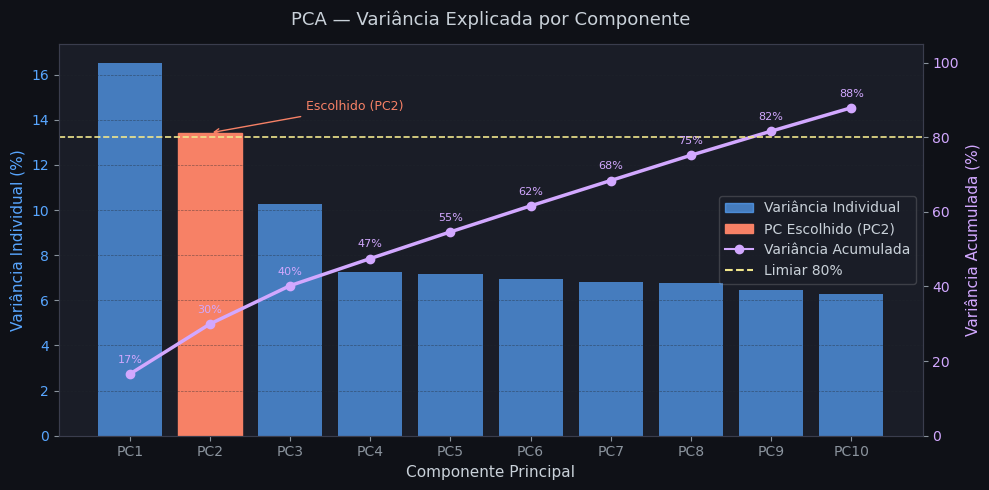

In [97]:
reduz_dados = PCA()
reduz_dados.fit(X_nivelado)

#explained_variance -> diz quanto cada super coluna capturou da variancia da tabela toda
#vai pegar o valor de explained... e vai somar uma por uma: 1 super coluna, depois 1 + 2, depois 1+2+3...n
variancia_individual = reduz_dados.explained_variance_ratio_
variancia_acumulada  = np.cumsum(variancia_individual)
n_components = min(10, len(variancia_individual))
indices = np.arange(1, n_components + 1)

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')

# Barras — variância individual
bars = ax1.bar(indices, variancia_individual[:n_components] * 100,
               color=PALETTE[0], alpha=0.7, label='Variância Individual (%)')

# Destaque PC escolhido (PC2)
bars[1].set_color(PALETTE[3])
bars[1].set_alpha(1.0)

ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Individual (%)', color=PALETTE[0])
ax1.set_xticks(indices)
ax1.set_xticklabels([f'PC{i}' for i in indices])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])
ax1.grid(True, axis='y')

# Linha — variância acumulada
ax2 = ax1.twinx()
ax2.set_facecolor('#1a1d27')
ax2.plot(indices, variancia_acumulada[:n_components] * 100,
         color=PALETTE[2], marker='o', linewidth=2.5, label='Variância Acumulada (%)')
ax2.axhline(y=80, color='#f0e68c', linestyle='--', linewidth=1.2, label='80% de Variância')
ax2.set_ylabel('Variância Acumulada (%)', color=PALETTE[2])
ax2.tick_params(axis='y', labelcolor=PALETTE[2])
ax2.set_ylim(0, 105)

# Anotações
for i, (ind, acu) in enumerate(zip(variancia_individual[:n_components], variancia_acumulada[:n_components])):
    ax2.annotate(f'{acu*100:.0f}%', xy=(i+1, acu*100),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8, color=PALETTE[2])

ax1.annotate('Escolhido (PC2)', xy=(2, variancia_individual[1]*100),
             xytext=(3.2, variancia_individual[1]*100 + 1),
             arrowprops=dict(arrowstyle='->', color=PALETTE[3]),
             color=PALETTE[3], fontsize=9)

# Legenda combinada
handles = [
    mpatches.Patch(color=PALETTE[0], alpha=0.7, label='Variância Individual'),
    mpatches.Patch(color=PALETTE[3], label='PC Escolhido (PC2)'),
    Line2D([0], [0], color=PALETTE[2], marker='o', label='Variância Acumulada'),
    Line2D([0], [0], color='#f0e68c', linestyle='--', label='Limiar 80%'),
]
ax1.legend(handles=handles, loc='center right', framealpha=0.2)

plt.title('PCA — Variância Explicada por Componente', pad=14)
plt.tight_layout()
plt.show()


vamos usar 30% devido trabalhar com 2 dimensões, ficando mais fácil de enxergar

In [98]:
reduz_dados2 = PCA(n_components=2, random_state=42)
X_pca = reduz_dados2.fit_transform(X_nivelado)
X_pca.shape

(1200, 2)

In [99]:
nomes = X.columns.tolist()
receita_pca = pd.DataFrame(
    reduz_dados2.components_.T,
    index=nomes,
    columns=['PC1', 'PC2']
)

#sinal serve para dizer o quanto da determianda coluna afeta a super coluna
#o PC1 aumenta se o deficit de sono aumenta, assim como o PC1 diminui se as horas de sono aumentam
print("Como o PCA é Calculado — PC1 (Eixo do Sono):")
top_pc1 = receita_pca["PC1"].abs().sort_values(ascending=False).head(5)
for feat, val in top_pc1.items():
    sinal = "+" if receita_pca.loc[feat, "PC1"] > 0 else "-"
    print(f"{sinal} {feat:35s} |loading| = {val:.3f}")

Como o PCA é Calculado — PC1 (Eixo do Sono):
+ deficit_sono                        |loading| = 0.537
- sleep_hours                         |loading| = 0.535
+ relacao_tela_sono                   |loading| = 0.526
+ screen_time_before_sleep            |loading| = 0.300
+ pontuacao_carga_mental              |loading| = 0.160


In [100]:
print("Como o PCA é Calculado — PC2 (Eixo da Carga Mental):")
top_pc2 = receita_pca["PC2"].abs().sort_values(ascending=False).head(5)
for feat, val in top_pc2.items():
    sinal = "+" if receita_pca.loc[feat, "PC2"] > 0 else "-"
    print(f"{sinal} {feat:35s} |loading| = {val:.3f}")

Como o PCA é Calculado — PC2 (Eixo da Carga Mental):
+ pontuacao_carga_mental              |loading| = 0.681
+ anxiety_level                       |loading| = 0.417
+ stress_level                        |loading| = 0.398
+ addiction_level                     |loading| = 0.382
- relacao_tela_sono                   |loading| = 0.143


In [101]:
print(f"PC1: {reduz_dados2.explained_variance_ratio_[0]*100:.1f}% -> Eixo do Sono")
print(f"PC2: {reduz_dados2.explained_variance_ratio_[1]*100:.1f}% -> Eixo da Carga Mental")
print(f"Total: {sum(reduz_dados2.explained_variance_ratio_)*100:.1f}%\n")

PC1: 16.5% -> Eixo do Sono
PC2: 13.4% -> Eixo da Carga Mental
Total: 30.0%



# ─────────────────────────────────────────────
# ESCOLHA DO K
# ─────────────────────────────────────────────

* K -> Número de Grupos que vai ser criado
* Inércia -> Mede o quão compactos estão os Grupos
* Silhueta -> Mede o quão parecido o adolescente é com o seu próprio grupo e o quão diferente ele é dos outros grupos

Quanto mais grupos eu crio, menor fica a inércia e a silhueta tem uma nota que vai de -1 a 1, sendo mais próximos do 1 = mais perfeitos e bem separados estão os grupos

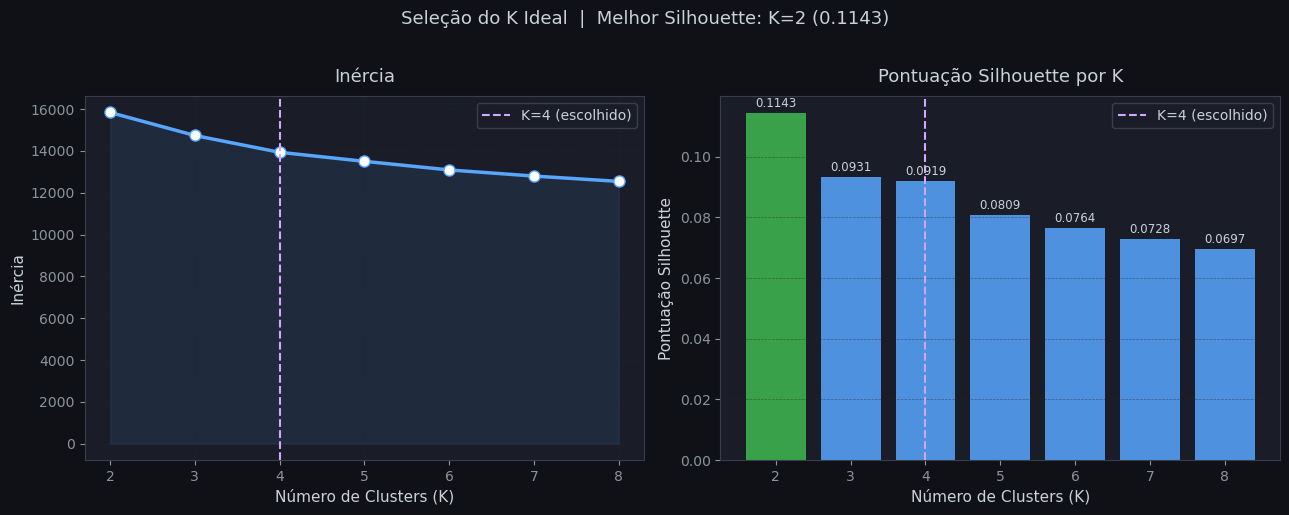

In [102]:
melhor_sil_k, melhor_sil = 2,0
inercias, silhouettes = [],[]
ks = range(2,9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupo = km.fit_predict(X_nivelado) #quem foi pra qual grupo
    inercia = km.inertia_
    sil = silhouette_score(X_nivelado, grupo)
    inercias.append(inercia)
    silhouettes.append(sil)
    if sil > melhor_sil:
        melhor_sil, melhor_sil_k = sil, k

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

# ----- Gráfico 1: Inércia -----
ax1.plot(list(ks), inercias, marker='o', color=PALETTE[0],
         linewidth=2.5, markersize=8, markerfacecolor='white')
ax1.fill_between(list(ks), inercias, alpha=0.1, color=PALETTE[0])
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia')
ax1.set_title('Inércia', pad=10)
ax1.set_xticks(list(ks))
ax1.grid(True)
# Marca K=4
ax1.axvline(4, color=PALETTE[2], linestyle='--', linewidth=1.5, label='K=4 (escolhido)')
ax1.legend(framealpha=0.2)

# ----- Gráfico 2: Silhouette -----
bar_colors = [PALETTE[1] if s == melhor_sil else PALETTE[0] for s in silhouettes]
bars = ax2.bar(list(ks), silhouettes, color=bar_colors, alpha=0.85, edgecolor='none')
ax2.axvline(4, color=PALETTE[2], linestyle='--', linewidth=1.5, label='K=4 (escolhido)')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Pontuação Silhouette')
ax2.set_title('Pontuação Silhouette por K', pad=10)
ax2.set_xticks(list(ks))
ax2.grid(True, axis='y')
for bar, sil in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{sil:.4f}', ha='center', fontsize=8.5, color='#c9d1d9')
ax2.legend(framealpha=0.2)

fig.suptitle(f'Seleção do K Ideal  |  Melhor Silhouette: K={melhor_sil_k} ({melhor_sil:.4f})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Para dados médicos, usaremos 4 grupos, e não 2, pois podemos ter casos: Saudável, Risco, Sono Comprometido e Sobrecarga Mental

# ─────────────────────────────────────────────
# K-MEANS
# ─────────────────────────────────────────────

In [103]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=20) #n_init garante que não acerte de primeira por sorte
grupos = km_final.fit_predict(X_nivelado) #quantidade de grupos

df['cluster'] = grupos
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['depression_label'] = y

sil_final = silhouette_score(X_nivelado, grupos)
print(f'Pontuação do Silhueta: {sil_final:.4f}')
print(f'Inércia: {km_final.inertia_:1f}')

Pontuação do Silhueta: 0.0922
Inércia: 13934.983879


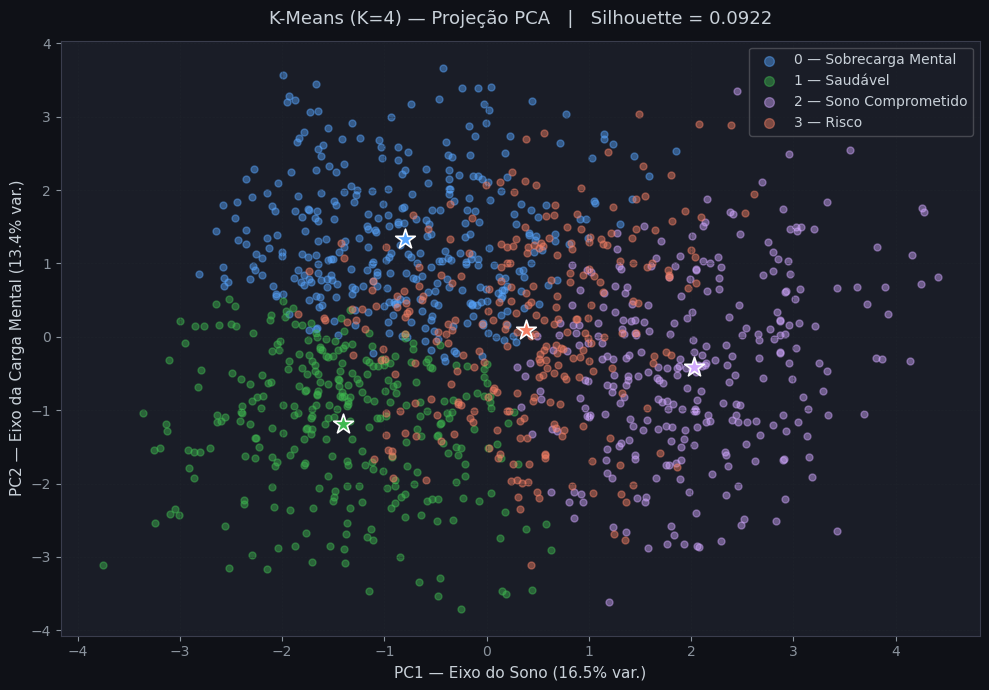

In [104]:
nomes_cluster = {0: 'Sobrecarga Mental', 1: 'Saudável',
                 2: 'Sono Comprometido', 3: 'Risco'}

# ---------- Scatter PCA ----------
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f1117')

# Centroids no espaço PCA
centroids_pca = km_final.cluster_centers_
centroids_2d  = reduz_dados2.transform(centroids_pca)

for c in range(4):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'PC1'], df.loc[mask, 'PC2'],
               color=PALETTE[c], alpha=0.45, s=25, label=f'{c} — {nomes_cluster[c]}')
    ax.scatter(centroids_2d[c, 0], centroids_2d[c, 1],
               color=PALETTE[c], edgecolors='white', s=220,
               marker='*', linewidths=1.2, zorder=5)

ax.set_xlabel(f"PC1 — Eixo do Sono ({reduz_dados2.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 — Eixo da Carga Mental ({reduz_dados2.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title(f'K-Means (K=4) — Projeção PCA   |   Silhouette = {sil_final:.4f}', pad=12)
ax.legend(loc='upper right', framealpha=0.25, markerscale=1.4)
ax.grid(True)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# NOMEAÇÃO CLÍNICA
# ─────────────────────────────────────────────

In [105]:
df.columns.tolist()

['age',
 'gender',
 'daily_social_media_hours',
 'platform_usage',
 'sleep_hours',
 'screen_time_before_sleep',
 'academic_performance',
 'physical_activity',
 'social_interaction_level',
 'stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label',
 'deficit_sono',
 'relacao_tela_sono',
 'pontuacao_carga_mental',
 'cluster',
 'PC1',
 'PC2']

In [106]:
#focado em comportamento dos adolescentes
colunas = [
    'daily_social_media_hours', 'sleep_hours', 'deficit_sono',
    'stress_level', 'anxiety_level', 'addiction_level',
    'physical_activity', 'screen_time_before_sleep', 'pontuacao_carga_mental',
    'depression_label'
]

perfil = df.groupby('cluster')[colunas].mean().round(2)
perfil['quantidade_adol'] = df['cluster'].value_counts().sort_index()
perfil['porcentagem'] = (perfil['quantidade_adol'] / len(df) * 100).round(1)

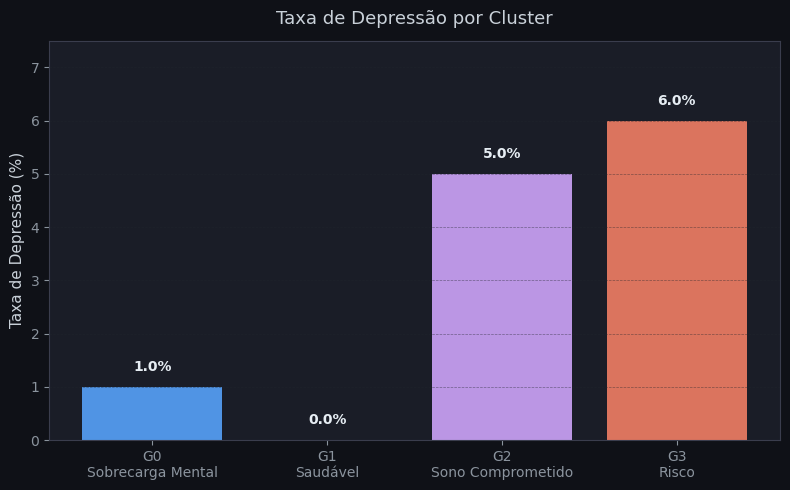

In [107]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0f1117')

grupo = [f'G{c}\n{nomes_cluster[c]}' for c in range(4)]
dep_rates = [perfil.loc[c, 'depression_label'] * 100 for c in range(4)]

bars = ax.bar(grupo, dep_rates, color=PALETTE, alpha=0.88, edgecolor='none')
for bar, val in zip(bars, dep_rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, color='#e6edf3', fontweight='bold')

ax.set_ylabel('Taxa de Depressão (%)')
ax.set_title('Taxa de Depressão por Cluster', pad=12)
ax.set_ylim(0, max(dep_rates) * 1.25)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

* Grupo 0: sono bom (~7.6h), stress alto (6.7), ansiedade alta (7.1) → Sobrecarga Mental
* Grupo 1: sono bom (~7.5h), stress baixo (4.0), ansiedade baixa (3.8) → Saudável
* Grupo 2: sono ruim (~5.1h), screen antes de dormir alto (2.4h) → Sono Comprometido
* Grupo 3: sono ruim (~5.2h), maior taxa de depressão (6%) → Risco

In [108]:
cluster_config = {
    1: {
        'nome': 'Saudável', 'icone': '⛨',
        'cor': '#3fb950', 'cor_fundo': '#152218',
        'borda_destaque': False,
        'metricas':  ['sleep_hours','stress_level','anxiety_level','daily_social_media_hours','pontuacao_carga_mental'],
        'labels':    ['Sono','Estresse','Ansiedade','SM/dia','Carga mental'],
        'maximos':   [8, 10, 10, 8, 10],
        'unidades':  ['h','','','h',''],
        'desc': 'Grupo de referência. Sono adequado, baixo estresse e ansiedade.\nNenhum caso de depressão registrado.',
    },
    0: {
        'nome': 'Sobrecarga Mental', 'icone': '◉',
        'cor': '#f0883e', 'cor_fundo': '#2b1a0a',
        'borda_destaque': False,
        'metricas':  ['sleep_hours','stress_level','anxiety_level','daily_social_media_hours','pontuacao_carga_mental'],
        'labels':    ['Sono','Estresse','Ansiedade','SM/dia','Carga mental'],
        'maximos':   [8, 10, 10, 8, 10],
        'unidades':  ['h','','','h',''],
        'desc': 'Sono preservado, mas estresse e ansiedade elevados.\nIntervenção: suporte emocional e manejo de estresse.',
    },
    2: {
        'nome': 'Sono Comprometido', 'icone': '☽',
        'cor': '#58a6ff', 'cor_fundo': '#0b1d33',
        'borda_destaque': False,
        'metricas':  ['sleep_hours','stress_level','anxiety_level','screen_time_before_sleep','pontuacao_carga_mental'],
        'labels':    ['Sono','Estresse','Ansiedade','Tela antes de dormir','Carga mental'],
        'maximos':   [8, 10, 10, 4, 10],
        'unidades':  ['h','','','h',''],
        'desc': 'Déficit de sono severo (~5h). Alto uso de tela antes de dormir.\nIntervenção: higiene do sono, desconexão digital noturna.',
    },
    3: {
        'nome': 'Risco', 'icone': '⚠',
        'cor': '#f78166', 'cor_fundo': '#2b0d0d',
        'borda_destaque': True,
        'metricas':  ['sleep_hours','stress_level','anxiety_level','addiction_level','pontuacao_carga_mental'],
        'labels':    ['Sono','Estresse','Ansiedade','Vício','Carga mental'],
        'maximos':   [8, 10, 10, 10, 10],
        'unidades':  ['h','','','',''],
        'desc': 'Combinação de sono ruim + carga mental elevada. Maior taxa\nde depressão. Prioridade máxima de intervenção clínica.',
    },
}

ORDEM   = [1, 0, 2, 3]
BG_PAGE = '#13151a'
BG_CARD = '#1e2128'

In [109]:
def pill(ax, x, y, w, h, cor, bg, txt, fs=10, bold=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.01', facecolor=bg,
        edgecolor=cor, linewidth=1.5))
    ax.text(x + w/2, y + h/2, txt, fontsize=fs,
            color=cor, va='center', ha='center',
            fontweight='bold' if bold else 'normal')

def hbar(ax, xl, xr, yc, h, frac, cor, bg='#2a2f38'):
    w = xr - xl
    ax.add_patch(FancyBboxPatch((xl, yc - h/2), w, h,
        boxstyle='round,pad=0.005', facecolor=bg, edgecolor='none'))
    if frac > 0.01:
        ax.add_patch(FancyBboxPatch((xl, yc - h/2), frac*w, h,
            boxstyle='round,pad=0.005', facecolor=cor, edgecolor='none'))

In [110]:
def draw_card(ax, cid):
    cfg = cluster_config[cid]
    cor, bg = cfg['cor'], cfg['cor_fundo']

    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_axis_off()

    # Contorno do card
    lw  = 2.8 if cfg['borda_destaque'] else 1.2
    ec  = cfg['cor'] if cfg['borda_destaque'] else '#2d3240'
    ax.add_patch(FancyBboxPatch((0.03, 0.03), 0.94, 0.94,
        boxstyle='round,pad=0.02', facecolor=BG_CARD,
        edgecolor=ec, linewidth=lw))

    # Pill — nome do cluster
    n   = int(perfil.loc[cid, 'quantidade_adol'])
    pct = perfil.loc[cid, 'porcentagem']
    pill(ax, 0.07, 0.855, 0.64, 0.085, cor, bg,
         f"{cfg['icone']}  {cfg['nome']} — {n} alunos ({pct}%)", fs=10)

    # Pill — depressão
    dep = perfil.loc[cid, 'depression_label'] * 100
    dep_txt = f"Depressão: {dep:.1f}%" + (" — maior taxa" if cid == 3 else "")
    pw = 0.46 if cid == 3 else 0.30
    pill(ax, 0.07, 0.755, pw, 0.072, cor, bg, dep_txt, fs=9.5)

    # Barras de progresso
    mets  = cfg['metricas']
    lbls  = cfg['labels']
    maxs  = cfg['maximos']
    units = cfg['unidades']
    n_b   = len(mets)

    y_top = 0.71;  y_bot = 0.24
    step  = (y_top - y_bot) / n_b
    bh    = 0.036
    xl, xr = 0.35, 0.83

    for i, (m, lbl, mx, u) in enumerate(zip(mets, lbls, maxs, units)):
        yc  = y_top - (i + 0.5) * step
        val = perfil.loc[cid, m]
        ax.text(xl - 0.025, yc, lbl, fontsize=9, color='#8b949e',
                va='center', ha='right')
        hbar(ax, xl, xr, yc, bh, min(val/mx, 1.0), cor)
        ax.text(xr + 0.025, yc, f"{val:.1f}{u}", fontsize=9,
                color='#c9d1d9', va='center', ha='left')

    # Descrição
    ax.text(0.07, 0.19, cfg['desc'], fontsize=8.5, color='#8b949e',
            va='top', ha='left', linespacing=1.6)

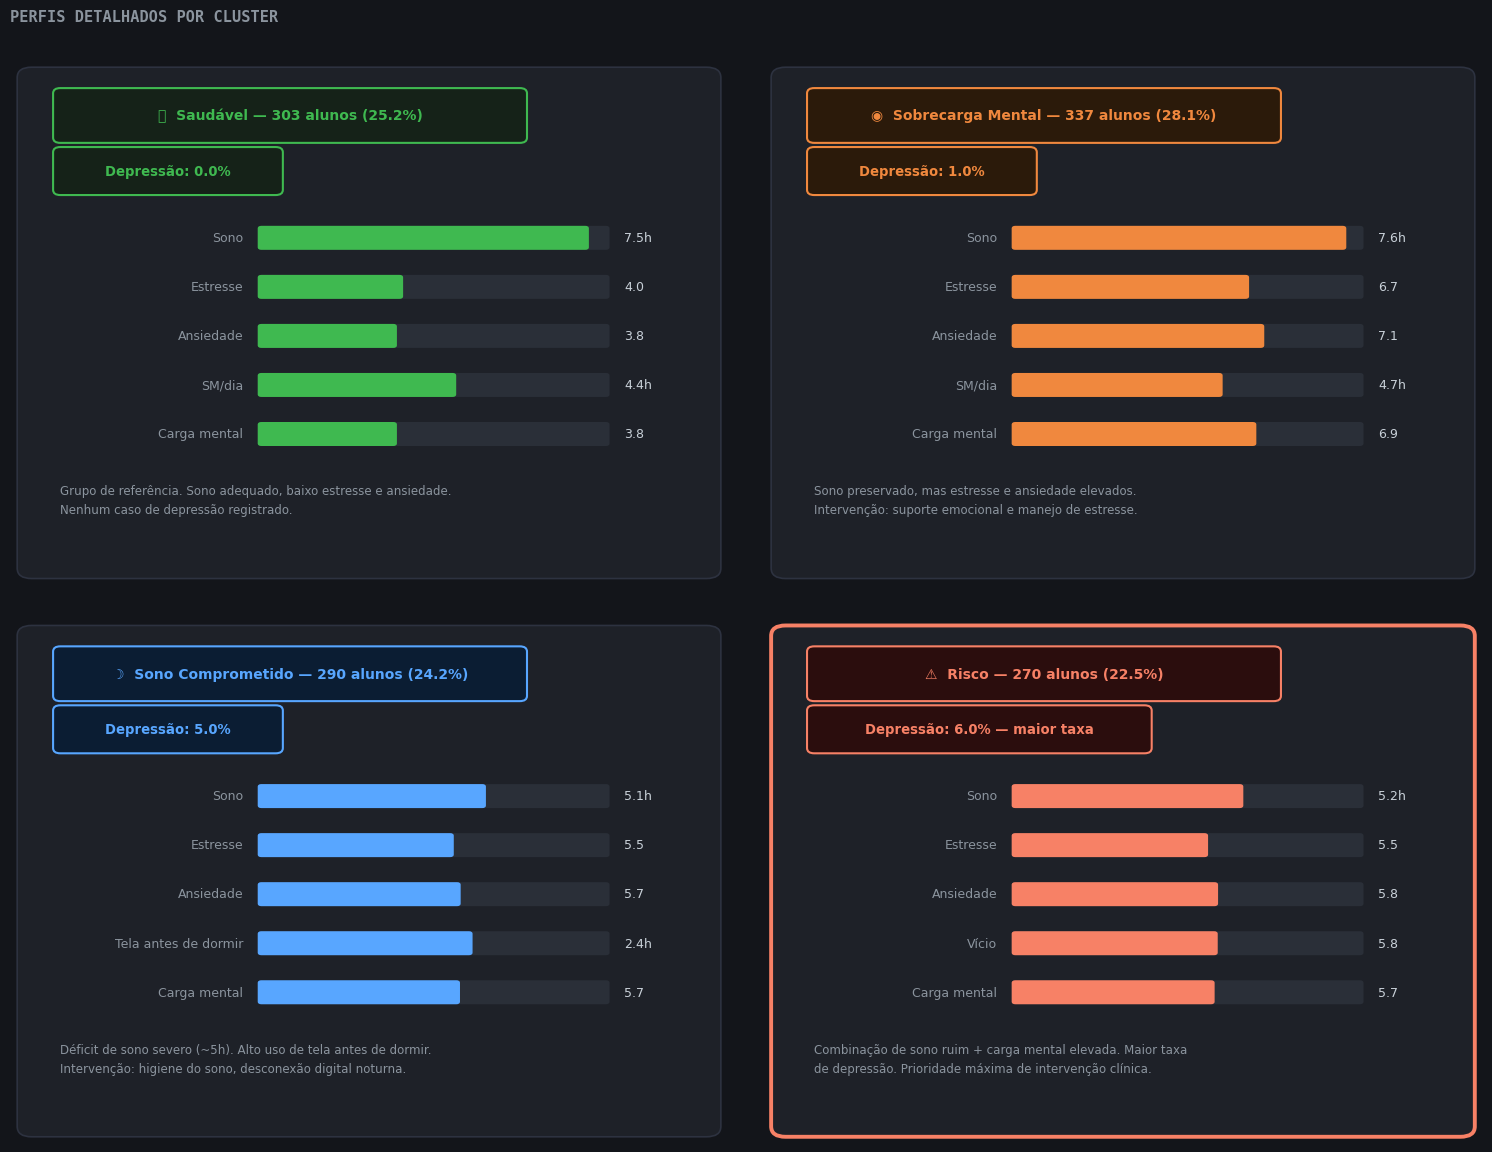

In [111]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(BG_PAGE)

fig.text(0.04, 0.974, 'PERFIS DETALHADOS POR CLUSTER',
         fontsize=11, fontweight='bold', color='#8b949e',
         va='top', ha='left', fontfamily='monospace')

gs = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.07, wspace=0.05,
                        left=0.04, right=0.96,
                        top=0.93, bottom=0.03)

for idx, cid in enumerate(ORDEM):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    draw_card(ax, cid)

plt.savefig('perfis_cluster_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG_PAGE)
plt.show()